<a href="https://colab.research.google.com/github/edoardochiarotti/class_datascience/blob/main/2024/03_EDA-Visualization/03_EDA_Data-visualization.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis and Data Visualization

<img src='https://imgs.xkcd.com/comics/convincing.png' width="650">

Source: [xkcd 833](https://xkcd.com/833/)

## Content

It's finally time to have fun with our data! Let's start exploring them to uncover the mysteries they are hiding...

- [What is Exploratory Data Analysis?](#EDA)
- [Descriptive statistics](#descriptive-statistics)
    - [Measures of Central Tendency](#central-tendency)
    - [Measures of Spread](#spread)
    - [Measures of Shape](#shape)
    - [Measures of Dependence](#dependence)
- [Data Visualization](#data-visualization)
    - [The power of visualization for EDA](#data-visualization-power)
        - [The cholera map that changed the world](#cholera-map)
        - [Visualizing the survivorship bias](#survivorship-bias)
    - [Which graph for what?](#graph)
    - [Communication rules and tips](#communication-rules)
        - [A bit more on colors...](#colors)
    - [The Data Visualization landscape in Python](#data-visualization-python)
- [EDA Application: Global Preference Survey](#EDA-application)
    - [Setting up the scenes: data acquisition](#EDA-data-acquisition)
    - [Descriptive Statistics](#EDA-descriptive-statistics)
    - [Box plot](#EDA-box-plot)
    - [Histogram](#EDA-histogram)
    - [Grouping](#EDA-grouping)
    - [Interactive box plot](#EDA-interactive-box-plot)
    - [Correlation](#EDA-correlation)
    - [Heat map](#EDA-heat-map)
    - [Scatter plot](#EDA-scatter-plot)
    - [Pair plot](#EDA-pair-plot)
    - [Map](#EDA-map)
    - [And much more...](#EDA-more)
- [Data Visualization Application: Green Domestic Product](#Data-Viz-application)
    - [Data acquisition](#Data-Viz-acquisition)
    - [Bar chart](#Data-Viz-bar-chart)
    - [Line chart](#Data-Viz-line-chart)
    - [Pie chart](#Data-Viz-pie-chart)
    - [Area chart](#Data-Viz-area-chart)
    - [GrDP Map](#Data-Viz-map)
    - [And so much more... Be creative!](#Data-Viz-more)

## What is Exploratory Data Analysis? <a name="EDA"></a>

Exploratory Data Analysis (EDA) is the process of **performing initial investigations** on the data so as to discover patterns, to spot anomalies, to test hypothesis and to check assumptions with the help of summary statistics and graphical representations. As we previously discussed, a Data Science project is an iterative process, so it's quite common that data cleaning and EDA happen at the same time, as one helps the other. EDA was promoted by [John Tukey](https://en.wikipedia.org/wiki/John_Tukey) to encourage statisticians to explore the data, and possibly formulate hypotheses that could lead to new data collection and experiments. 

EDA consists of two main processes:
- **Getting an overview of data** using summary numbers such as **descriptive statistics**,
- **Visualizing** your variables and their relations.

EDA allows to:
- identify data quality issues: does something look wrong? If so, you need additional cleaning!
- select your variables:
     - is there redundancy between our explanatory variables? If so, we might not need all of them...
     - do we observe some association between our dependent and independent variables? Causation implies association, so if you do not find some association, you might have an issue! By the way, you probably know that correlation does not imply causation. But can you have causation without correlation? Yes, you can! For example, you might have some non-linear relation between your variables. So causation implies association, but does not imply correlation! Read the article [Association, correlation and causation](https://www.nature.com/articles/nmeth.3587) by Naomi Altman & Martin Krzywinski to learn more!
- select your sample: e.g., is your dataset balanced (e.g., same number of observations for each unit/country/year)? If not, you may need additional cleaning... or additional data
- prepare your data: do you need to normalize the data? Or apply some logarithmic transformation? Or another technique?
- choose the right statistical tools / ML algorithms: it depends, among other things, on the type of your data (continuous, categorical, binary, etc.).
- get an idea of the underlying variation: How do variables varies over time? Over space? Can you spot anomalies or interesting shocks to exploit for a natural experience?
- ... and much more!

We will discover in this notebook some EDA techniques. You can also always use Quentin Gallea's [recipe to empirically answer any question rapidly](https://towardsdatascience.com/a-recipe-to-empirically-answer-any-question-quickly-22e48c867dd5).

## Descriptive statistics <a name="descriptive-statistics"></a>

**Descriptive statistics** are very useful to get a first overview of our data. They allow to:
- Describe the basic characteristics of the data at hand, often one variable at a time.
- Summarizes the data such that meaningful and easily understandable patterns emerge

However, descriptive statistics **do not allow** making conclusions or **inferences** beyond the sample of the data being analyzed.

### Measures of Central Tendency <a name="central-tendency"></a>

Several statistics measure the central tendency and spread of our data:
- Mode: most frequent value, i.e., that appears most often
- Mean ("average"): sum of all values divided by number of observations $\mu=\frac{\sum_{i=1}^n x_i}{n}$
- Median: middle value of a sorted data set, i.e., value that divides our sample into two halves

The mean is sensitive to extreme values and outliers, while the median is more resistant, as illustrated below. So which measure is the best? Well, **there is no best, but using only one is definitely worst**! Depending on your data, some measurements are more meaningful than others, but using them together is always better.

<img src='https://miro.medium.com/v2/resize:fit:1400/format:webp/0*wHMvuwRa_YF9SFwY.png' width="600">

Image by Nhan Tran, [Mean, Median, and Mode in Statistics](https://medium.com/@nhan.tran/mean-median-an-mode-in-statistics-3359d3774b0b)

### Measures of Spread <a name="spread"></a>

Several measures return information on the dispersion of data:
- Minimum: lowest value
- Maximum: highest value
- Range: (maximum - minimum)
- Percentile: the p-percentile is the value so that p percent of the values are below it  
- Quartiles: special case of percentiles, dividing our distribution into quarters: Q1 (25%), Q2 (50% - median), Q3 (75%)
- Variance: Average of squared differences from mean $\sigma^2=\frac{\sum_{i=1}^n (x_i - \mu)^2}{n}$
- Standard Deviation: Square root of variance $\sigma=\sqrt{\frac{\sum_{i=1}^n (x_i - \mu)^2}{n}}$


### Measures of Shape <a name="shape"></a>


- Skewness: measure of the asymmetry

<div>
<img src="https://upload.wikimedia.org/wikipedia/commons/f/f8/Negative_and_positive_skew_diagrams_%28English%29.svg?utm_source=fr.wikipedia.org&utm_campaign=index&utm_content=original" width="450"/>
</div>

Image by Rodolfo Hermans (Godot), Wikipedia [Skewness](https://en.wikipedia.org/wiki/Skewness)

- Kurtosis: measure of the "tailedness"

<div>
<img src="https://i.ibb.co/854XVgd/Kurtosis.jpg" width="400"/>
</div>

### Measures of Dependence <a name="dependence"></a>

- Pearson correlation coefficient: $r_{xy}=\frac{\sum_{i=1}^n (x_i - \mu_x)(y_i - \mu_y)}{\sqrt{\sum_{i=1}^n (x_i - \mu_x)^2}\sqrt{\sum_{i=1}^n (y_i - \mu_y)^2}}$
    - Measures the linear relationship between two paired sets of values
    - Measures the direction (+ or -)
    - Measures the strength (between 0 and 1)

<div>
<img src="https://upload.wikimedia.org/wikipedia/commons/d/d4/Correlation_examples2.svg?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=original" width="700"/>
</div>

Image by DenisBoigelot, [Wikipedia Pearson correlation coefficient](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient)

As seen on the above image, two variables can have zero/low (Pearson) correlation, but still be related. Linear correlation is a special type of relatedness measure, not the only one. There exist many other more sophisticated measures...  

## Data Visualization <a name="data-visualization"></a>


### The power of visualization for EDA <a name="data-visualization-power"></a>

Visualization helps identify patterns, clusters, and gaps in your data. It is good for spotting the unexpected. 

#### The cholera map that changed the world <a name="cholera-map"></a>

In the 19th century, there was frequent large-scale epidemics of cholera in European cities. The source of the disease was not known, or misunderstood. Actually, in the world of the 1850s, cholera was believed to be spread by [*miasma*](https://en.wikipedia.org/wiki/Miasma_theory), i.e., some kind of air pollution. Everything changed in 1854 with an English physician, [John Snow](https://en.wikipedia.org/wiki/John_Snow). He decided to map the cases of an epidemic in the Soho district of London. Soon, a culprit emerged: all the cases were clustered around the water pump in Broad street. John Snow's investigation demonstrated that contaminated water was the key source of the epidemics of cholera, and the removal of the handle led to cessation of the epidemic. His contribution - originating from a map - was key to promote better sanitation, and hence decrease public health issues due to waterborne diseases.

Read the article [John Snow, Cholera, the Broad Street Pump; Waterborne Diseases Then and Now](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7150208/) by Theodore H. Tulchinsky to learn more!

<div>
<img src="https://blog.rtwilson.com/wp-content/uploads/2012/01/SnowMap_Points.png" width="450"/>
</div>

#### Visualizing the survivorship bias <a name="survivorship-bias"></a>

The [survivorship bias](https://en.wikipedia.org/wiki/Survivorship_bias), survival bias or immortal time bias is the logical error of concentrating on the people or things that made it past some selection process and overlooking those that did not, typically because of their lack of visibility. This can lead to incorrect conclusions regarding that which (or those who) didn't make it.

Consider the image below, illustrating the hypothetical damage pattern on a returning plane during World War 2. Which parts of the plane would you reinforce?

<div>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b2/Survivorship-bias.svg/1920px-Survivorship-bias.svg.png" width="400"/>
</div>

Source: Wikipedia - [Survivorship bias](https://en.wikipedia.org/wiki/Survivorship_bias) Based on a not-illustrated report by Abraham Wald (1943), picture concept by Cameron Moll (2005, claimed on Twitter and credited by Mother Jones), new version by McGeddon based on a Lockheed PV-1 Ventura drawing (2016), vector file by Martin Grandjean (2021).

If the aircraft was reinforced in the most commonly hit areas, this would be a result of survivorship bias. Indeed, the returning plane was still able to fly despite the bullet impacts (in red). However, fatally damaged planes are the ones that were presumably hit in the other locations!

### Which graph for what? <a name="graph"></a>

We have discussed above that data visualization is a powerful tool for Exploratory Data Analysis. Obviously, visualization is also incredibly powerful to communicate and disseminate your results. After all, a (good) graph speak thousands words! And people understand pictures better than read numbers.

Although in both cases - EDA and dissemination - you are dealing with graphs, the process is much different:
- For EDA, you are a detective trying to uncover the mysteries behind your data. Each clue is welcome! Hence, you should not hesitate to try things. And try again. Explore different combinations of variables. Explore subsets of your data. Plot many graphs without spending much time of the design (although your graph should still be understandable by you and your team). And repeat until you have a good understanding of your dataset, your variables, their evolution and patterns.
- For dissemination, your goal is very different. Your are a lawyer trying to convince the jury - your audience - that your case is solid. Design and style matters. Concision matters. Each graph should be informative, easily understandable, and serve a clear purpose.

In both cases, you should be creative. Still, some types of graphs are more suited to the task at hand. The "best" chart depends on what you want to show/explore, on the type of data, and of the features of your variables. You have a forest of options. The decision tree below, designed by the [Extreme Precision method](https://extremepresentation.com/), provides some suggestions to pinpoint which chart to use depending on your goal and on your data. It should not be understood as mandatory rules, rather helpful advice.

<div>
<img src="http://anonymity94.github.io/assets/img/Chart-Suggestion-A-Thought-Starter.abb20ab5.png" width="1100"/>
</div>

### Communication rules and tips <a name="communication-rules"></a>

Your figures should illustrate every main message and major contribution. But just because you understand your visualization does not mean others will! Here are 4 important rules of visualization:
1. "Keep It Simple"!
2. Design and choose the visualization well
3. Know your audience and tell a story
    - Who is your audience?
        - What experiences do you share? What are common goals?
    - What do they know?
        - What information is most valuable to my audience?
        - What role will my visuals play in this dialog?
    - Why should they care?
        - What motivates them? What will surprise them?
    - Which message do you want to convey?
        - What actions do I want to incite?
4. Have graphical integrity
    - Avoid truncating your axis
    - Be careful of "3D manipulation"

Also, here are a few tips to improve your plots:
- Title/Caption your figures; your title should be descriptive enough
- Label your axes
- Label intervals
- Lines vs dots:
    - Dots are data points
    - Lines are often results of a model (simulation, statistical analysis)
- When using text inside your visualization:
    - Use spell check
    - Use sufficiently large police for people to read it
- Select your colors wisely
    - Use a limited palette
    - How a color project on a screen is different than how they print: test it!
- Your graph should be readable in black & white
    - Choose colors with sufficient contrast
    - You can use different symbols, solid vs dashed vs dotted lines, etc.
- Be consistent!
    - Text police and alignment, scale, colors, symbols and style of lines, etc. all have a meaning

To further improve your visualization, you can read the article by Nicolas Rougier ,Michael Droettboom, and Philip Bourne [Ten Simple Rules for Better Figures](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1003833).

#### A bit more on colors... <a name="colors"></a>

As mentioned above, your visualization should be readable in black & white (e.g., when printed). Color contrast is key. Below is a wheel of color and how they look in black & white:

<div>
<img src="https://www.robertnajlis.com/wp-content/uploads/2015/05/BYR_color_wheel.png" width="200"/> 
<img src="https://www.robertnajlis.com/wp-content/uploads/2015/05/BYR_color_wheel_BW.png" width="200"/>    
</div>

Colors have connotation and can reflect moods. Depending on your message, you might want to use different colors:

<div>
<img src="https://colourlex.com/wp-content/uploads/2021/02/manganese-blue-painted-swatch-300x300.jpg.webp" width="15" height="15"/>  Calming  
</div>
<div>
<img src="https://colourlex.com/wp-content/uploads/2021/02/arylide-yellow-painted-swatch-300x300.jpg.webp" width="15" height="15"/>  Optimistic 
</div>
<div>
<img src="https://colourlex.com/wp-content/uploads/2021/02/Emerald-green-painted-swatch-300x300.jpg.webp" width="15" height="15"/>  Nature-friendly  
</div>
<div>
<img src="https://colourlex.com/wp-content/uploads/2021/03/orange-ochre-painted-swatch-france-300x300.jpg.webp" width="15" height="15"/>  Energetic  
</div>
<div>
<img src="https://colourlex.com/wp-content/uploads/2021/02/cadmium-red-painted-swatch-300x300.jpg.webp" width="15" height="15"/>  Dynamic  
</div>
<div>
<img src="https://colourlex.com/wp-content/uploads/2021/02/Manganese-violet-painted-swatch-300x300.jpg.webp" width="15" height="15"/>  Mystic  
</div>


However, in different contexts, the meaning is also different: e.g., red/green for stop/go, red/blue for hot/cold, white/black for on/off, etc. 

Also, be aware that each culture associates different meanings with colors. So do not hesitate to adjust the colors you use based on your audience.

Last but not least, be aware of [color blindness](https://www.colourblindawareness.org/colour-blindness/types-of-colour-blindness/). For instance, worldwide, about 8% of men and 0.5% of women have a red/green type of color vision deficiency. You can check [colorblindawareness.org](https://www.colourblindawareness.org/colour-blindness/types-of-colour-blindness/) to learn more about the types of color blindness. Here is below an illustration they did, showing what the majority of people would see (left), the Deuteranopia sight (center), and the Tritanopia sight (right).

<div>
<img src="https://www.colourblindawareness.org/wp-content/uploads/2021/11/pigment.jpg" width="250"/>
<img src="https://www.colourblindawareness.org/wp-content/uploads/2021/11/pigment_d.jpg" width="250"/>     
<img src="https://www.colourblindawareness.org/wp-content/uploads/2021/11/pigment_t.jpg" width="250"/> 
</div>


### The Data Visualization landscape in Python <a name="data-visualization-python"></a>

Now that we discussed what we want to do, how do we actually do it? We discussed in our last notebook the diversity of libraries, packages, and modules, displaying the strength of Python: its community. Well, it's gonna be wild - and potentially confusing - with visualization libraries and packages! 

[Matplotlib](https://matplotlib.org/) is the most common one. It is a comprehensive library for creating static, animated, and interactive visualizations. Originally, it was created by John D. Hunter to design MATLAB-like plots (hence, its name), but with its continuous development it now offers much more. 

Inspired by Matplotlib, many libraries/packages were developed to introduce new features and facilitates some operations, such as [seaborn](https://seaborn.pydata.org/), [plotnine](https://plotnine.readthedocs.io/en/stable/) or even [pandas](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html).

Then, developers designed packages that use JavaScript, which are well suited for interactivity in browsers, e.g., [bokeh](https://docs.bokeh.org/en/latest/) and [plotly](https://plotly.com/python/).

You can see below an overview of the Python visualization landscape by Nicolas Rougier ([GitHub repository](https://github.com/rougier/python-visualization-landscape)) from 2017 (so it is already outdated). Jake VanderPlas, one of the authors of [Altair](https://altair-viz.github.io/), used it during his [talk at PyCon](https://www.youtube.com/watch?v=FytuB8nFHPQ).

<div>
<img src="https://github.com/rougier/python-visualization-landscape/blob/master/landscape-colors.png?raw=true" width="700"/>
</div>

We will use in this course several of these packages, as a way of discovering them. There is no best package: it depends a bit on the task at-hand, and mostly on your personal preferences.

The [Python Graph Library](https://www.python-graph-gallery.com/) is a collection of hundreds of charts made with Python - with the associated code. It is an incredible resource when you are looking for graph ideas! Feel free to further explore this wonderful complex world of data visualization in Python, design creative visualizations, and have fun!

<div>
<img src="https://i.postimg.cc/XY925Ry8/Python-graph.png" width="500"/>
</div>

## EDA Application: Global Preference Survey <a name="EDA-application"></a>

In this section, we will illustrate the Exploratory Data Analysis process using as example the [Global Preferences Survey](https://www.briq-institute.org/global-preferences/home). It is a globally representative dataset on risk and time preferences, positive and negative reciprocity, altruism, and trust. The following paper is a nice read about the survey:

Falk, A., Becker, A., Dohmen, T., Enke, B., Huffman, D., & Sunde, U. (2018). Global evidence on economic preferences. *The Quarterly Journal of Economics*, 133(4), 1645-1692. DOI: [10.1093/qje/qjy013](https://academic.oup.com/qje/article/133/4/1645/5025666?login=false).

### Setting up the scenes: data acquisition <a name="EDA-data-acquisition"></a>

We first import `pandas` and `numpy`. Remember, as a good practice, you should import all the packages you are using at the top of your notebook - here we only import the packages progressively to introduce the new packages we are going to use...

In [1]:
import pandas as pd
import numpy as np

Let's now import our datasets as `pandas` data frame. We are using data from the Global Preference Survey, available in a CSV file in our GitHub repository.

In [2]:
# Import dataset on Global Preference Survey from GitHub
df_gps = pd.read_csv("https://raw.githubusercontent.com/thurmboris/Data-Science_4_Sustainability/main/data/global_preference_survey.csv")

Let's use `.head()` to visualize what kind of data we are dealing with:

In [3]:
df_gps.head(7)

,iso3,patience,risktaking,posrecip,negrecip,altruism,trust
0,AFG,-0.201360,0.120764,0.289641,0.254712,0.166455,0.315964
1,DZA,0.059815,0.391530,-0.598255,0.254901,-0.009968,-0.177371
2,ARG,-0.229308,0.041503,0.159679,-0.140457,0.027347,-0.206733
3,AUS,0.657004,0.137137,0.069660,0.022190,0.155331,0.298973
4,AUT,0.608285,-0.061829,0.161047,-0.055415,-0.035363,0.154628
5,BGD,0.081137,-0.198068,0.154368,0.113288,0.906463,-0.173365
6,BOL,0.071331,0.103038,0.107920,-0.003735,-0.005187,-0.160330


Let's also check the type of our data to check if the data was correctly imported:

In [4]:
df_gps.dtypes

iso3              str
patience      float64
risktaking    float64
posrecip      float64
negrecip      float64
altruism      float64
trust         float64
dtype: object

It seems alright: the iso3 column is `object` - as it should be since it consists of strings (iso 3 country codes) - and the preference variables are `float32`. 

Below, we will perform some EDA tasks to better understand the Global Preference Survey data.

### Descriptive Statistics <a name="EDA-descriptive-statistics"></a>

With `pandas`, we can use the `.describe()` method to get a data frame containing the most common descriptive statistics. The method summarizes the central tendency, dispersion and shape of a dataset’s distribution. Note that:
- it excludes `NaN` values
- it analyzes both numeric and object series, as well as variables of mixed data types. The output will vary depending on what is provided. Check the [documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html) 

Note that instead of using `.describe()`, we could also directly compute the statistics of interest, and you can even specify the "axis", i.e., measure for a given variable (row-wise, by default) or observation (column-wise, axis = 1). 

|Function|Description|
|:-------|:----------|
|`.count()` | Count non-NA cells |
|`.mean()` | Return the mean of the values |
|`.std()` | Return sample standard deviation  |
|`.min()` | Return the minimum of the values  |
|`.median()` | Return the median of the values |
|`.quantile(q=0.5)` | Return values at the given quantile *q* |
|`.max()` | Return the maximum of the values |

In [5]:
df_gps.describe()

,patience,risktaking,posrecip,negrecip,altruism,trust
count,76.000000,76.000000,76.000000,76.000000,76.000000,76.000000
mean,-0.003421,0.012658,-0.033612,0.013159,-0.037569,-0.022146
std,0.369663,0.301881,0.341819,0.275397,0.343334,0.277795
min,-0.612520,-0.792435,-1.037981,-0.489312,-0.939617,-0.706439
25%,-0.257605,-0.157406,-0.242433,-0.167865,-0.239602,-0.177403
50%,-0.092516,-0.019577,0.024422,0.003909,-0.097151,-0.081175
75%,0.131628,0.163387,0.186954,0.182523,0.154469,0.153361
max,1.071452,0.970596,0.569985,0.738908,0.906463,0.609021


The first row counts the number of observations. Here, we have 76 observations, i.e., countries in our dataset, that are not `NaN`. Then, we have common descriptive statistics.

### Box plot <a name="EDA-box-plot"></a>

Box and whisker plots - also called box plots - are a clever way of visualizing the distribution of a set of numerical data using only one dimension. They allow to:
- identify outliers (i.e., anomalies)
- check if your data is skewed or symmetrical.
- visually compare several variables or data subsets

The box extends from the Q1 to Q3 quartile values of the data, with a line at the median (Q2). The whiskers extend from the edges of box to show the range of the data. Generally, they extend no more than 1.5$*$IQR (IQR = Q3 - Q1) from the edges of the box, ending at the farthest data point within that interval. Outliers are plotted as separate dots.

<div>
<img src="https://miro.medium.com/v2/format:webp/1*ghJQrcLZXGWxDPzppLWULA.png" width="500"/>
</div>

Image by Valentina Alto [Introduction to Box Plots and how to interpret them](https://medium.com/analytics-vidhya/introduction-to-box-plots-and-how-to-interpret-them-22464acbcba7)

One way to generate a box plot is to directly use the `.boxplot()` method available in the pandas package. You can specify the variables and several [options](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.boxplot.html).

Matplotlib is building the font cache; this may take a moment.


<Axes: >

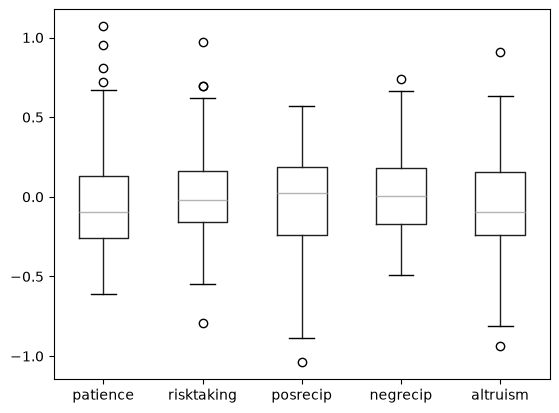

In [6]:
df_gps.boxplot(column =['patience', 'risktaking', 'posrecip', 'negrecip', 'altruism'], grid = False)

What do we observe? Some observations are outside the whiskers. Are they outliers that we should remove? Probably not. Still, in one visual, we are able to detect such patterns, and asymmetries.

### Histogram <a name="EDA-histogram"></a>

A histogram is a summary of the variation in a measured variable. It works by binning the entire range of values into a series of intervals and then counting how many values fall in each interval. 

Learn more about how to select the number of bins in a histogram by reading the article by He & Meeden (1997), [Selecting the number of bins in a histogram: A decision theoretic approach](https://doi.org/10.1016/S0378-3758(96)00142-5), published in the *Journal of Statistical Planning and inference*, 61(1), pages 49-59.

We'll do a histogram of the "risktaking" variable. Let's discover a new graph library, the most common of them all, [Matplotlib](https://matplotlib.org/). We import the [pyplot](https://matplotlib.org/3.5.1/api/_as_gen/matplotlib.pyplot.html) module.

In [7]:
import matplotlib.pyplot as plt 

We create a histogram using the `.hist()` function ([Documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html)). It is using the `.histogram()` function of NumPy to compute the values and the edges of the histogram ([Documentation](https://numpy.org/doc/stable/reference/generated/numpy.histogram.html)).

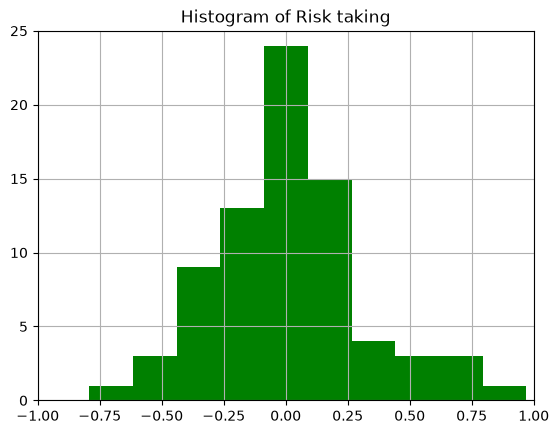

In [8]:
plt.hist(df_gps.loc[:,"risktaking"],       # risktaking column as argument
         color = "g")                      # color in green
plt.title('Histogram of Risk taking')      # Title your figure!
plt.xlim(-1, 1)       # Specify x-axis range
plt.ylim(0, 25)       # Specify y-axis range
plt.grid(True)        # Add grid
plt.show()            # Display graph

### Grouping <a name="EDA-grouping"></a>

Let's continue our exploration! We have looked at statistics for the whole dataset (including all the observations) but it is often interesting to explore subset of data. For example, you could group your data by region, gender, age, etc. Here, we will create two clusters, one with the observations for which the altruism value is (strictly) lower than the mean altruism, the second with the observations for which the altruism value is greater than the mean altruism.

In the code below, we create a new column, called 'Cluster'. We populate this column with value equal to zero if the altruism is strictly lower than the mean of altruism (-0.037569), and with one otherwise:

In [9]:
altruism_mean = df_gps['altruism'].mean()

df_gps.loc[df_gps['altruism'] < altruism_mean, 'Cluster'] = 0
df_gps.loc[df_gps['altruism'] >= altruism_mean, 'Cluster'] = 1

df_gps.head(9)

,iso3,patience,risktaking,posrecip,negrecip,altruism,trust,Cluster
0,AFG,-0.201360,0.120764,0.289641,0.254712,0.166455,0.315964,1.0
1,DZA,0.059815,0.391530,-0.598255,0.254901,-0.009968,-0.177371,1.0
2,ARG,-0.229308,0.041503,0.159679,-0.140457,0.027347,-0.206733,1.0
3,AUS,0.657004,0.137137,0.069660,0.022190,0.155331,0.298973,1.0
4,AUT,0.608285,-0.061829,0.161047,-0.055415,-0.035363,0.154628,1.0
5,BGD,0.081137,-0.198068,0.154368,0.113288,0.906463,-0.173365,1.0
6,BOL,0.071331,0.103038,0.107920,-0.003735,-0.005187,-0.160330,1.0
7,BIH,-0.247258,-0.125639,0.096463,0.429355,-0.115310,-0.193106,0.0
8,BWA,0.233990,0.697379,-0.258667,-0.172722,-0.142062,-0.338462,0.0


Now we can access descriptive statistics for our two subsets (0 = low altruism; 1= high altruism). We can use the method `.groupby()` ([Documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)) to group the data according to some categories and then apply a function to the categories. For example, let's group by low/high altruism values and `.count()` the number of observations in our clusters: 

In [10]:
df_gps.groupby('Cluster').count()

,iso3,patience,risktaking,posrecip,negrecip,altruism,trust
Cluster,,,,,,,
0.0,43,43,43,43,43,43,43
1.0,33,33,33,33,33,33,33


We have 43 observations (countries) with low altruism and 33 with high altruism. This is due to the lack of symmetry of the altruism variable. 

### Interactive box plot <a name="EDA-interactive-box-plot"></a>

We have mentioned above that box plots allow to visually compare subsets of our data. We will illustrate this by creating box plots of the variables 'posrecip' and 'negrecip' for: a) countries with low altruism; b) country with high altruism. Instead of using the pandas `.boxplot()` method, let's try another library! We are going to use [plotly](https://plotly.com/python/), a common library for interactive graphs. We first import the `plotly.express` module. [Plotly Express](https://plotly.com/python/plotly-express/) provides more than 30 functions for creating different types of figures. 

In [11]:
import plotly.express as px

Now let's create our box plot, using `.box()`:

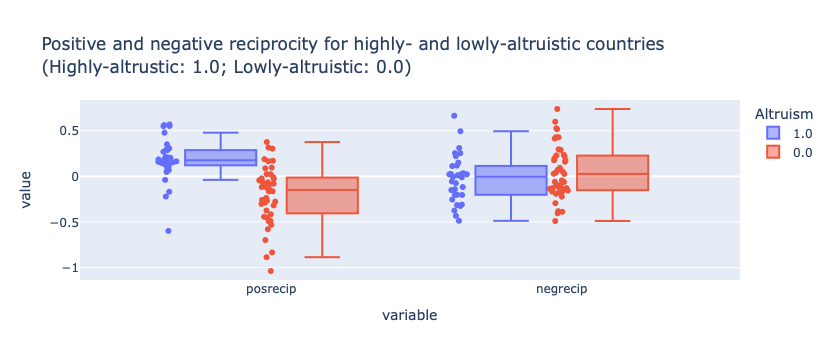

In [12]:
fig_box = px.box(df_gps,                                           # Specify data frame
                 y=["posrecip", "negrecip"],                       # Select posrecip and negrecip variables
                 points="all",                                     # Include all observations as data points
                 color = "Cluster",                                # Color (and group by) column "Cluster"
                 labels = {"Cluster": "Altruism"},                 # Rename "Cluster" as "Altruism" in our legend
                 title = """Positive and negative reciprocity for highly- and lowly-altruistic countries 
                 <br>(Highly-altrustic: 1.0; Lowly-altruistic: 0.0)""")       # Always add a title!
fig_box.update_layout(autosize=False, width = 800)                # Specify width (by default, full notebook cell)
fig_box

Try to hover over the above plot... Amazing isn't it?! Not only do we have a nice visual, we can also directly check the actual values behind the plot! And have you noticed on the top right? There is a modebar allowing to zoom and even download your plot as a PNG image.  

Alright, we can do cool graphs, but what did we learn? It seems that the countries with high altruism tend to also have higher value of positive reciprocity, while this is not true for negative reciprocity. In other words, it seems that altruism and positive reciprocity are positively correlated, but altruism and negative reciprocity are not...

### Correlation <a name="EDA-correlation"></a>

Let's confirm our previous observation by computing the correlation matrix between our variables. We can use the `.corr()` pandas method. As argument, you can specify the method of correlation - by default Pearson. Check the [documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)!  

In [13]:
gps_corr = df_gps.loc[:,"patience":"trust"].corr()
gps_corr

,patience,risktaking,posrecip,negrecip,altruism,trust
patience,1.000000,0.230358,0.015539,0.258087,-0.010385,0.189909
risktaking,0.230358,1.000000,-0.256096,0.192764,-0.015175,-0.061453
posrecip,0.015539,-0.256096,1.000000,-0.153624,0.711019,0.363077
negrecip,0.258087,0.192764,-0.153624,1.000000,-0.131952,0.159890
altruism,-0.010385,-0.015175,0.711019,-0.131952,1.000000,0.272735
trust,0.189909,-0.061453,0.363077,0.159890,0.272735,1.000000


Our previous guess was correct, altruism and positive reciprocity are strongly correlated (0.711) while altruism and negative reciprocity are weakly correlated (-0.132).

### Heat map <a name="EDA-heat-map"></a>

Heatmaps are a method of representing data graphically where values are depicted by color, making it easy to visualize complex data and understand it at a glance.

For example, we can represent our correlation matrix. We will use the `.imshow()` function of `plotly.express` ([Documentation](https://plotly.com/python/heatmaps/)).

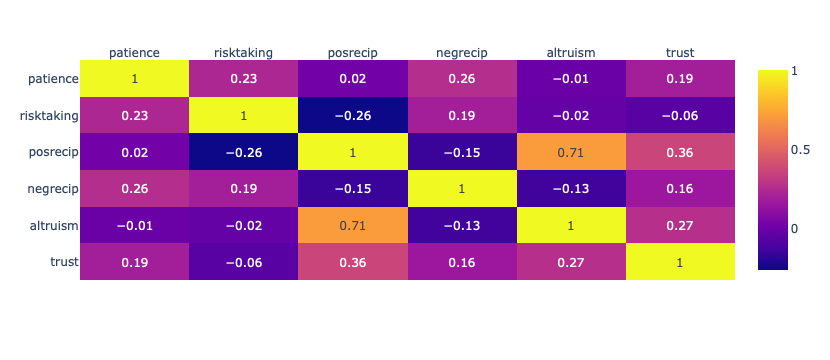

In [14]:
heatmap_corr = px.imshow(
    gps_corr.values.round(2),         # correlation matrix values, rounded at 2 decimals
    x=list(gps_corr.columns),         # label x-axis
    y=list(gps_corr.index),           # label y-axis
    text_auto=True,                   # add values to the graph
    aspect="auto"                     # automatically adjust aspect (without the option: square)
)
heatmap_corr.update_xaxes(side="top")   # display labels on top (by default: bottom)
heatmap_corr.show()

### Scatter plot <a name="EDA-scatter-plot"></a>

We have discussed before that two variables could be related despite having a low Pearson correlation. To check whether that is the case, we could compute other, more sophisticated correlation coefficients. However, there is an arguably better way: use visualization such as scatter plots!

Let's create a scatter plot between the "patience" and "trust" variables using the `.scatter` function ([Documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)) of Matplotlib.

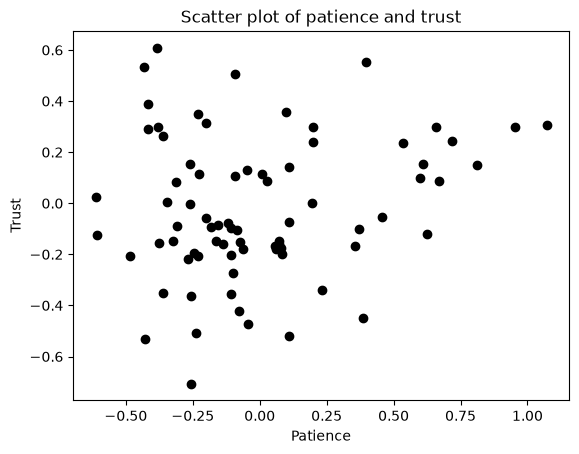

In [15]:
plt.scatter(df_gps.loc[:,"patience"],   # 1st argument is the x-axis series of points ("patience")
            df_gps.loc[:,"trust"],      # 2nd argument is the y-axis series of points ("trust")
            c = "black"                 # Color of data points            
           )
plt.title("Scatter plot of patience and trust")     # Always title your figure!
plt.xlabel("Patience")                              # Label your axis! 
plt.ylabel("Trust")
plt.show()

From the scatter plot, we can quickly visualize the relation (or lack thereof) between our variables.

### Pair plot <a name="EDA-pair-plot"></a>

The scatter plot above was convenient to visualize the relation between patience and trust. What if we want to do the same with our other variables? Should we repeat the same lines of code, each time manually changing the column? No! Should we create a function and do a for loop? That would be a better solution, but there is still a more efficient solution. We can do a pair plot.

Let's try it to better understand. We will use yet another library: [seaborn](https://seaborn.pydata.org/)

In [16]:
import seaborn as sns
%matplotlib inline

We use the `.pairplot()` function ([Documentation](https://seaborn.pydata.org/generated/seaborn.pairplot.html)). By default, pair plots display a grid of plots with: 
- histograms along the diagonal
- scatter plots for each pairing of variables

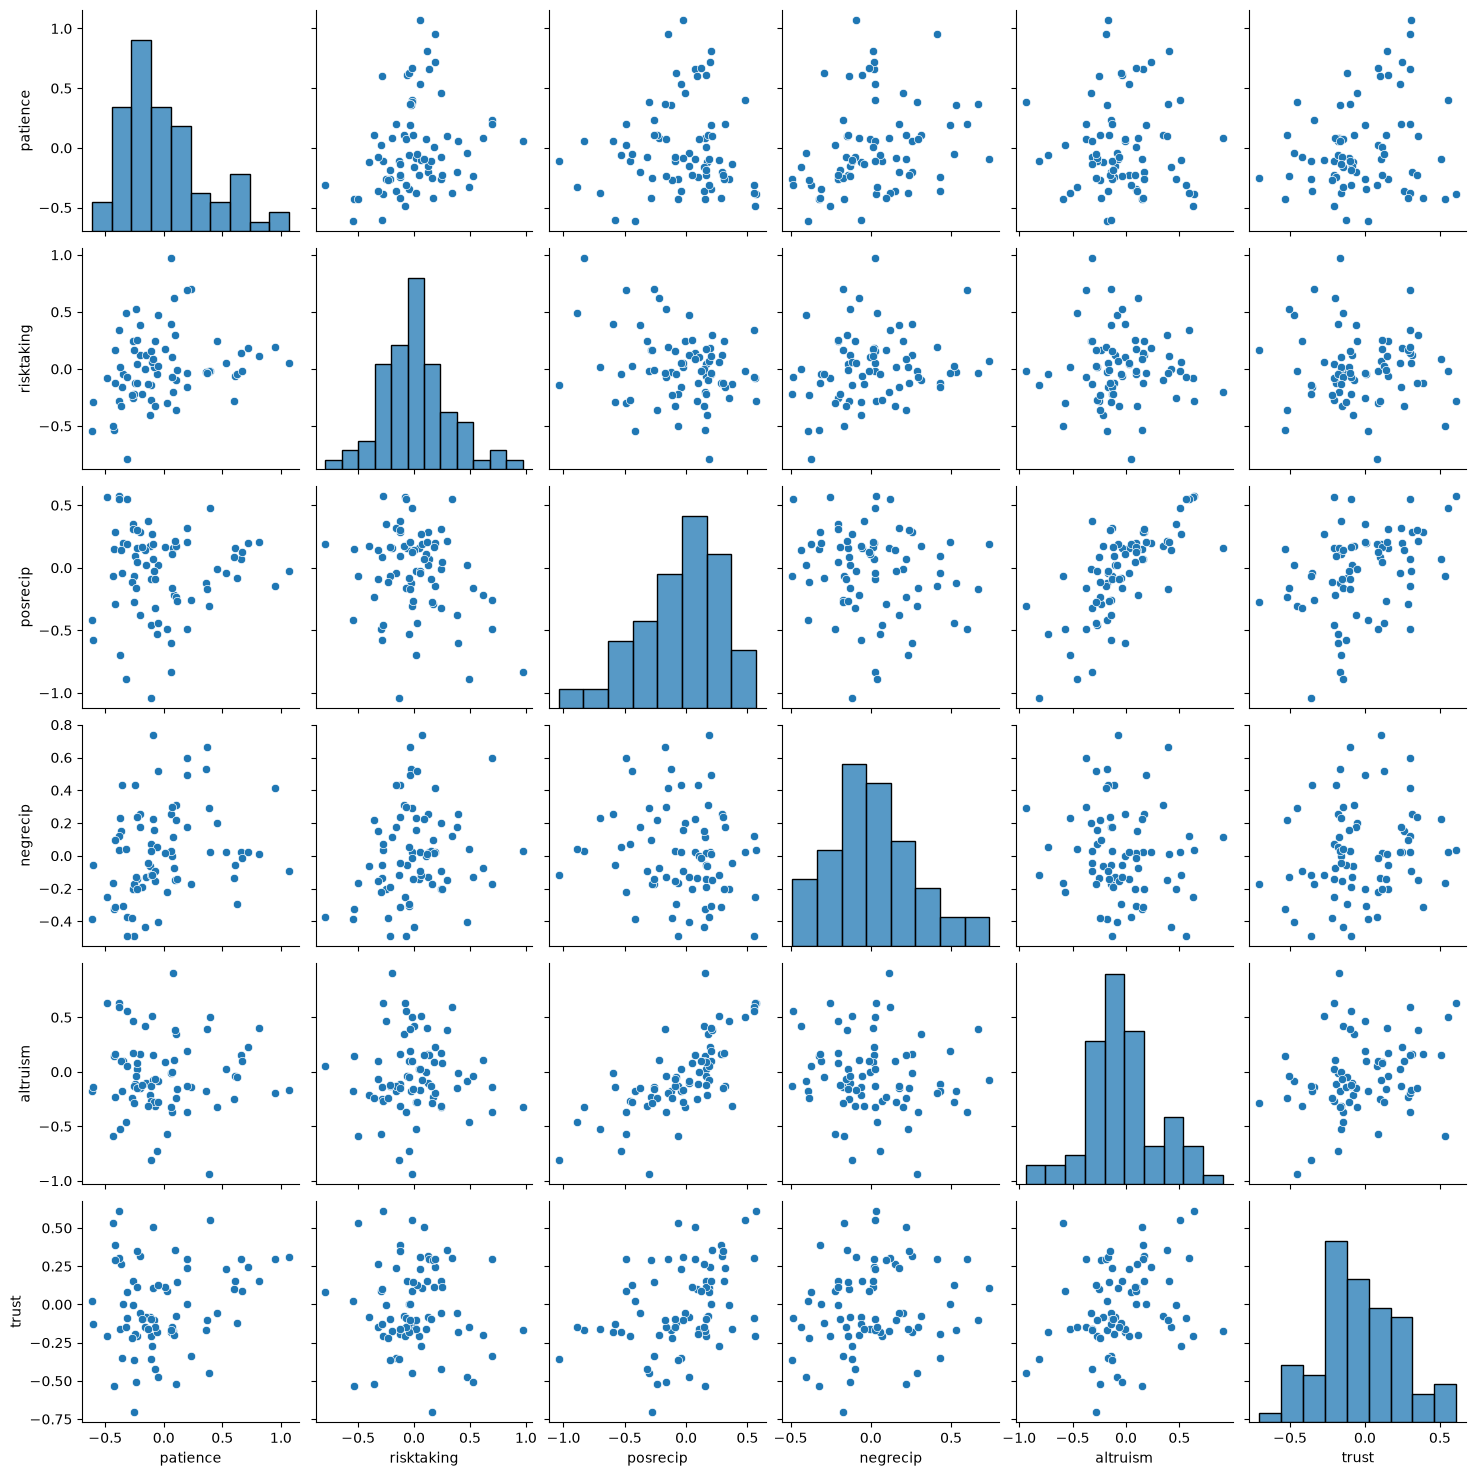

In [17]:
sns.pairplot(df_gps.loc[:,"patience":"trust"])      # dataframe as argument

We can even play a bit with the options, for instance coloring our observations based on some grouping. Let's try coloring low/high altruism!

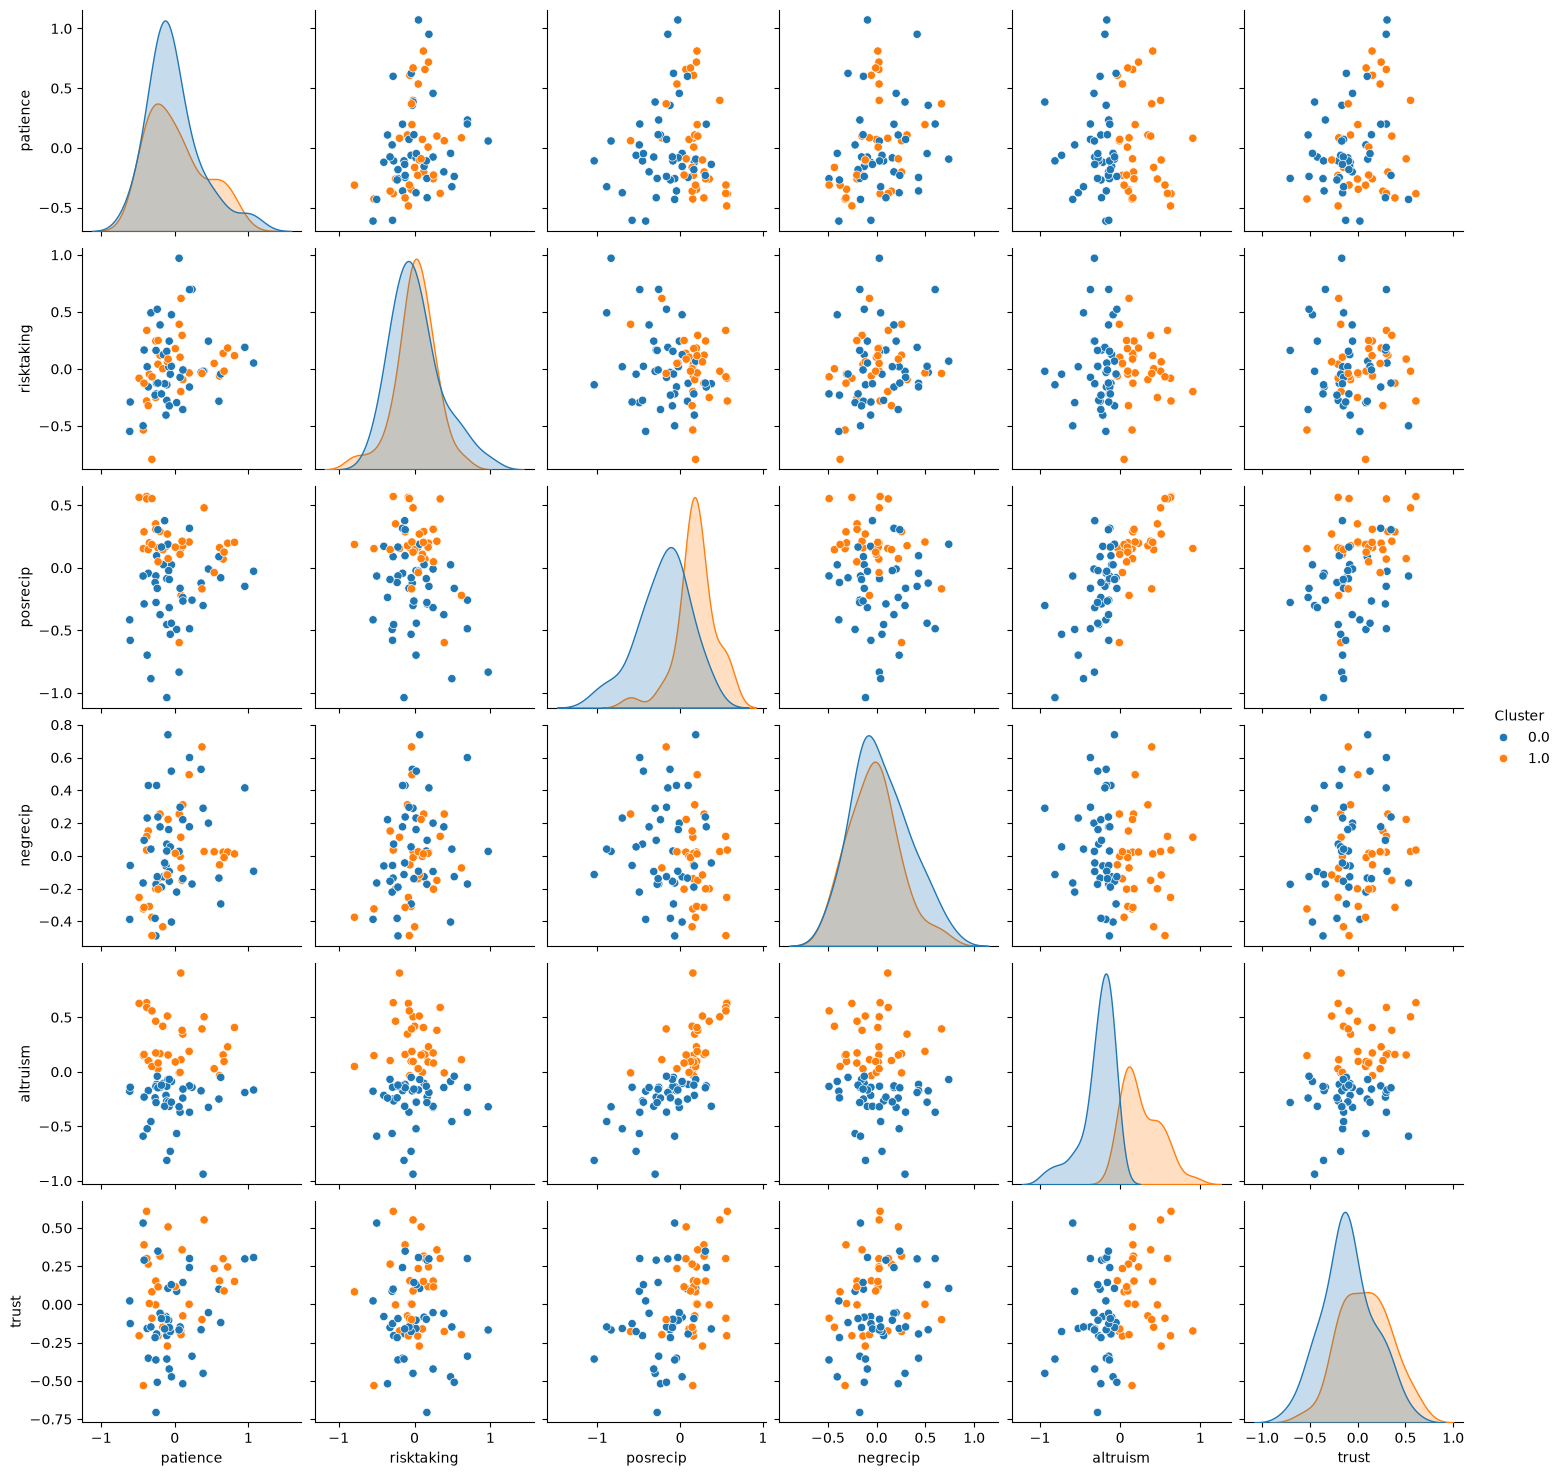

In [18]:
sns.pairplot(df_gps,        # dataframe as argument
                hue="Cluster"   # color (group) by high/low altruism
                )

As you can see, on the diagonal, the histograms were replaced by layered kernel density estimate (KDE), which is a method for visualizing the distribution of observations by representing the data using a continuous probability density curve ([Documentation](https://seaborn.pydata.org/generated/seaborn.kdeplot.html)).

### Map <a name="EDA-map"></a>

Maps are a powerful technique to visualize geographic data. They allow to:
- identify missing regions
- identify potential geographical patterns, i.e., how variables vary with, for instance, development level, population, geography (mountains, coastal areas), etc. 

We will plot a map of the level of altruism per country using the `.chloropleth()` function of `pyplot.express` ([Documentation](https://plotly.github.io/plotly.py-docs/generated/plotly.express.choropleth.html)). 

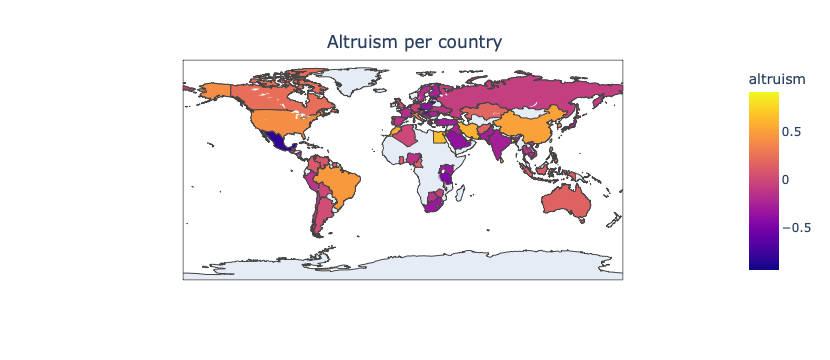

In [19]:
map_gps = px.choropleth(
    df_gps,                                 # dataframe as argument
    locations="iso3",                       # column name with location
    locationmode="ISO-3",                   # location method
    color="altruism",                       # color countries with altruism value
    color_continuous_scale=px.colors.sequential.Plasma,   # choice of colors
)
map_gps.update_layout( 
    title={                                # Add a title, centered on top
        'text': "Altruism per country",
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})
map_gps.show()

### And much more... <a name="EDA-more"></a>

We have explored our Global Preference Survey dataset, discovering a few techniques and graph libraries. Our Exploratory Data Analysis does not stop here, and there is much more mysteries to uncover! Keep on exploring until you feel you have a deep understanding of your data and their relations. Be creative in the techniques, descriptive statistics, and visualizations you use. And remember to have fun! 

## Data Visualization Application: Green Domestic Product <a name="Data-Viz-application"></a>

In this section, we illustrate some data visualization techniques using the Green Domestic Product (GrDP), which we computed in our previous notebook.

### Data acquisition <a name="Data-Viz-acquisition"></a>

Let's import the GrDP CSV file we generated in our last lecture as `pandas` data frame.

In [20]:
# Import dataset on Green Domestic Product from GitHub
url_grdp = 'https://raw.githubusercontent.com/thurmboris/Data-Science_4_Sustainability/main/data/GrDP_1995-2019.csv'
df_grdp = pd.read_csv(url_grdp)

df_grdp.head()

,Country,Year,GDP [million Euro],Population,Emissions_GHG [thousand tonnes CO2eq],Emissions_NOx [tonne],Emissions_PM2.5 [tonne],Emissions_PM10 [tonne],Emissions_SOx [tonne],Emissions_NMVOC [tonne],...,External cost Pb,External cost Cd,External cost Hg,External cost As,External cost Ni,External cost Cr,Total external cost,GrDP [million Euro],GrDP per capita [Euro],Share external cost [%]
0,Belgium,1995,220251.5,10130574.0,151311.86,415990,44400,60940,257720,306530,...,6408.607,925.875,50.709,66.264,1.704,100.128,159875.86700,6.037563e+04,5959.744532,72.587868
1,Bulgaria,1995,14512.8,8427418.0,54038.12,181900,19780,43710,1302010,140310,...,12003.939,740.700,33.806,165.660,0.672,31.290,105129.31431,-9.061651e+04,-10752.583331,724.390292
2,Czechia,1995,46008.4,10333161.0,147738.40,384910,120370,163110,1058970,391100,...,8458.060,370.350,67.612,187.748,0.672,53.193,201302.71255,-1.552943e+05,-15028.732500,437.534695
3,Denmark,1995,141441.4,5215718.0,84425.26,290300,24500,36200,145770,212670,...,845.806,185.175,33.806,11.044,0.312,9.387,34270.90287,1.071705e+05,20547.601908,24.229754
4,Germany,1995,1977604.1,81538603.0,1090715.50,2195580,205640,346170,1751450,2340450,...,22186.142,3518.325,338.060,99.396,4.992,294.126,692560.50726,1.285044e+06,15759.941248,35.020180


### Bar chart <a name="Data-Viz-bar-chart"></a>

Bar chart - also called bar graph - presents categorical data with rectangular bars with heights or lengths proportional to the values that they represent (categorical means that the variable can take on one of a limited number of possible values). For example, we can do a bar chart of the GrDP per capita in 2019, each bar representing the value for one country. This visualization allows a comparison between our countries.

Let's try another library, namely `bokeh`. [Bokeh](https://docs.bokeh.org/en/latest/) is suitable to create interactive visualizations for modern web browsers. It is a low-level plotting library, i.e., you have lots of flexibility in choosing what you want to do. As a compromise, it requires expertise to make decisions along the way. Ok, let's import the package we will need: 

In [21]:
# Import bokeh plotting package (must have explicit import of submodules)
import bokeh.io
import bokeh.models
import bokeh.plotting

# Enable viewing Bokeh plots in the notebook
bokeh.io.output_notebook()

Loading BokehJS ...

We will do a bar chart with the GrDP per capita for each country in 2019. In the code below, we extract the relevant columns ("Country" and "GrDP per capita") and the observations from 2019. We also use the pandas method `.sort_values()` ([Documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html)) to reverse sort the observations, from highest to lowest GrDP per capita: 

In [22]:
grdp_country_2019 = (df_grdp.loc[df_grdp["Year"]==2019, ["Country","GrDP per capita [Euro]"]]
                     .sort_values(by=["GrDP per capita [Euro]"], ascending=False))

We can start generating our figure. The first step is to actually create our figure, i.e., our "canvas", before populating it with data ("painting"). We use `bokeh.plotting.figure()`, and specify the shape of the figure (height and width), axis and labels. Here, we want to do a horizontal bar chart, so the x-axis will be the values of GrDP per capita and our countries will be on the y-axis. We could add [many more customizations](https://docs.bokeh.org/en/latest/docs/reference/models/plots.html#bokeh.models.plots.Plot), such as a title of the figure, whether or not to have grid lines, etc.

In [23]:
bar_grdp = bokeh.plotting.figure(
    frame_height=400,
    frame_width=400,
    x_axis_label='GrDP per capita in 2019 (in Euros)',
    y_range = grdp_country_2019["Country"][::-1],
)

Next step is to paint our figure. We need data. It is convenient to create a `ColumnDataSource`, a special Bokeh object that holds data to be displayed in a plot. We can do so directly from our data frame:

In [24]:
source_data = bokeh.models.ColumnDataSource(grdp_country_2019)

Now we can decide what kind of graph we want to create and populate it with data. We use `hbar`([Documentation](https://docs.bokeh.org/en/2.4.2/docs/reference/models/glyphs/hbar.html)). Once we are done creating our figure, and specifying the desired options, we can render it in the notebook using `bokeh.io.show()`.

In [25]:
bar_grdp.hbar(
    source=source_data,        # our data
    y="Country",               # Country on the y-axis
    right='GrDP per capita [Euro]', #GrDP per capita on the x-axis, to the right
    height=0.6                 # height of bars
)

# Turn off gridlines on categorical axis
bar_grdp.ygrid.grid_line_color = None

# Start axes at origin on quantitative axis
bar_grdp.x_range.start = 0

bokeh.io.show(bar_grdp)

Here you go! The sorting allows a nice shape - although you might prefer ordering your country by alphabetical order if the goal is to easily find the value of one country. Also, remember our interactive box plot we did? Here we have a similar bar on the right, allowing to zoom and save our figure.

### Line chart <a name="Data-Viz-line-chart"></a>

Line charts are use to present ordered numerical data. For instance, let's consider the evolution of GrDP in Switzerland. Clearly, the data is ordered, from oldest to latest observation.

In [26]:
grdp_ch = df_grdp.loc[df_grdp["Country"]=="Switzerland", ["Year", "Country" ,"GrDP [million Euro]"]]
grdp_ch

,Year,Country,GrDP [million Euro]
28,1995,Switzerland,220845.848176
58,1996,Switzerland,221466.666723
88,1997,Switzerland,216230.619279
118,1998,Switzerland,228732.609288
148,1999,Switzerland,239825.546029
178,2000,Switzerland,264299.993771
208,2001,Switzerland,283014.413276
238,2002,Switzerland,293793.429546
268,2003,Switzerland,285952.209751
298,2004,Switzerland,291444.213328


We will plot this evolution using `plotly.express.line` ([Documentation](https://plotly.com/python-api-reference/generated/plotly.express.line.html)). We quickly discussed above that Bokeh was a low-level library. By contrast, the [Plotly express](https://plotly.com/python/plotly-express/) module is more high-level: you can quickly do advanced plots, and only need to specify a few options.

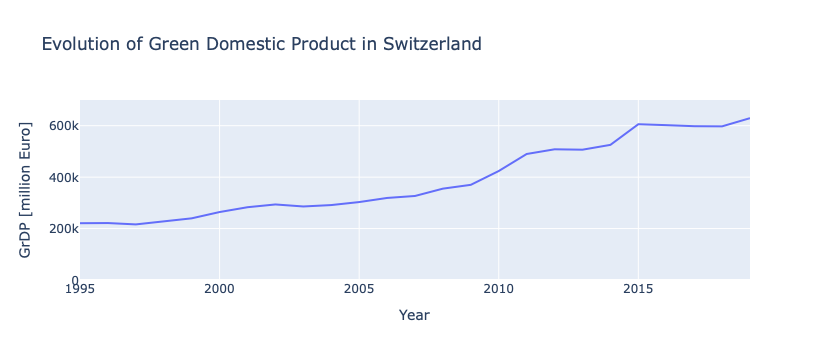

In [27]:
evol_grdp_ch = px.line(grdp_ch,     # data frame as argument
                       x="Year",    # x-axis: years
                       y="GrDP [million Euro]",    # y-axis: GrDP
                       title="Evolution of Green Domestic Product in Switzerland",  # title!
                       range_y= [0,700000]      # specify range to avoid truncation!
                      )
evol_grdp_ch.show()

As before with Plotly express, when you hover over the line, it displays the actual value, a very convenient interactive feature! The GrDP is, overall, increasing in Switzerland, a result of both an increase in GDP and a decrease in pollution, as we will see later.

### Pie chart <a name="Data-Viz-pie-chart"></a>

Pie charts are mostly used to understand relative amount, i.e., which category is bigger and which one is smaller. As an advice, do not use too many classes (i.e., no more than 8) to help the readability of the chart.

Let's try to understand which category of pollutant (greenhouse gases, air pollutants, heavy metals) represent the largest share of external costs in Switzerland in 2019. We'll first create two new columns in our data frame, summing the external costs of pollutants according to their type. Note that GHG is already an independent category and does not require such action.

In [28]:
df_grdp["External Cost Air Pollutant"] = (df_grdp["External cost NOx"]
                                          + df_grdp["External cost PM2.5"]
                                          + df_grdp["External cost PM10"]
                                          + df_grdp["External cost SOx"]
                                          + df_grdp["External cost NMVOC"]
                                          + df_grdp["External cost NH3"])
df_grdp["External Cost Heavy Metal"] = (df_grdp["External cost Pb"]
                                          + df_grdp["External cost Cd"]
                                          + df_grdp["External cost Hg"]
                                          + df_grdp["External cost As"]
                                          + df_grdp["External cost Ni"]
                                          + df_grdp["External cost Cr"])

We now extract the observations we wish to display, i.e., the external costs for each group of pollutant in Switzerland in 2019.

In [29]:
cost_ch_2019 = (df_grdp.loc[(df_grdp["Country"]=="Switzerland") & (df_grdp["Year"]==2019), 
                            ["External cost GHG", "External Cost Air Pollutant","External Cost Heavy Metal"]])

To make it more convenient to create our pie chart, we need to re-format a bit our data frame. Instead of having three columns with the external cost for each pollutant group, we need one column with the type of pollutant and another with the associated external cost. We first use the `.transpose()` method of pandas ([Documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.transpose.html)), and then we rename our column. Indeed, due to the transposition, the new column name became the previous line index! Finally, we add a new column with the names of the groups of pollutant (GHG, Air Pollutant, Heavy Metal):

In [30]:
cost_ch_2019 = cost_ch_2019.transpose().rename(columns={748: "External Cost"})
cost_ch_2019["Pollutant"]=["GHG","Air Pollutant","Heavy Metal"]

cost_ch_2019

,External Cost,Pollutant
External cost GHG,4618.069050,GHG
External Cost Air Pollutant,19002.145396,Air Pollutant
External Cost Heavy Metal,690.043000,Heavy Metal


Alright, we are all set to design our pie chart. We use `plotly.express.pie` ([Documentation](https://plotly.com/python-api-reference/generated/plotly.express.pie.html)):

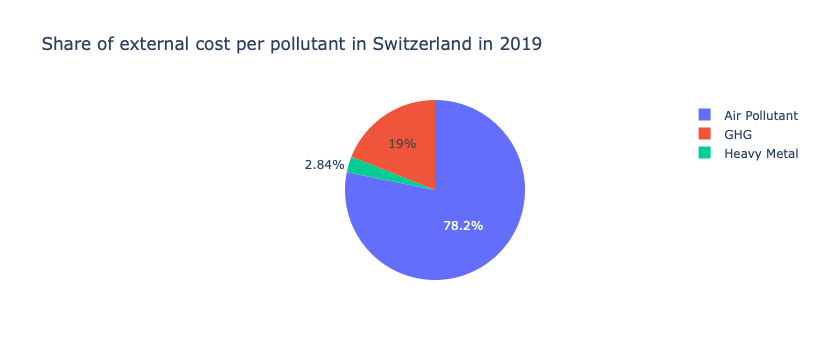

In [31]:
pie_cost = px.pie(cost_ch_2019,               # data frame as input
             values="External Cost",     # values to create the pie chart (data frame column name)
             names="Pollutant",          # labels (data frame column name)
             title="Share of external cost per pollutant in Switzerland in 2019")  # title!
pie_cost.show()

In Switzerland, air pollutants accounted for the majority of the external costs in 2019, mainly due to their negative impacts on health. The actual results depend on the choice of marginal damage costs, especially for GHG. In our [E4S white paper](https://e4s.center/en/resources/reports/green-domestic-product/), we explore several alternative scenarios. In the most pessimistic scenario regarding the impacts of climate change, the share of GHG in the total external costs is about the same as the one of air pollutants. 

### Area chart <a name="Data-Viz-area-chart"></a>

The above pie chart provided a static picture of what was happening in 2019. How did the cost of pollutants evolved through time though? To answer this question visually, we can design a (filled) area chart.

Let's prepare our data. We first extract the external costs per group of pollutants (previously calculated) for Switzerland.

In [32]:
cost_ch = (df_grdp.loc[(df_grdp["Country"]=="Switzerland"), 
                            ["Year", "External cost GHG", "External Cost Air Pollutant","External Cost Heavy Metal"]])

We now reorganize our data. We will create a data frame with three columns: year, group of pollutant, and associated value of external cost. 

To do so, we create three lists, containing the values of our 3 columns: 

In [33]:
obs = len(cost_ch)
pol = ["GHG"]*obs+["Air Pollutant"]*obs+["Heavy Metal"]*obs
year = list(cost_ch["Year"])*3
cost = list(cost_ch["External cost GHG"])+list(cost_ch["External Cost Air Pollutant"])+list(cost_ch["External Cost Heavy Metal"])

We then create a dictionary, with keys the name of the column, and values the lists previously computed. Finally, we create our data frame from our dictionary

In [34]:
dico_cost_ch ={"Year":year, "Pollutant":pol, "External cost":cost}
df_cost_ch = pd.DataFrame(data=dico_cost_ch)

Let's check the result to be sure we got it right - you should actually check each step of your code, that's what I did when I designed this notebook, before deleting the unnecessary lines of codes for clarity!

In [35]:
df_cost_ch

,Year,Pollutant,External cost
0,1995,GHG,5143.59195
1,1996,GHG,5045.48520
2,1997,GHG,5095.00320
3,1998,GHG,5363.06820
4,1999,GHG,5386.93155
...,...,...,...
70,2015,Heavy Metal,690.04300
71,2016,Heavy Metal,690.04300
72,2017,Heavy Metal,690.04300
73,2018,Heavy Metal,690.04300


Alright, we are ready to create our area chart with `plotly.express.area` ([Documentation](https://plotly.com/python-api-reference/generated/plotly.express.area.html))

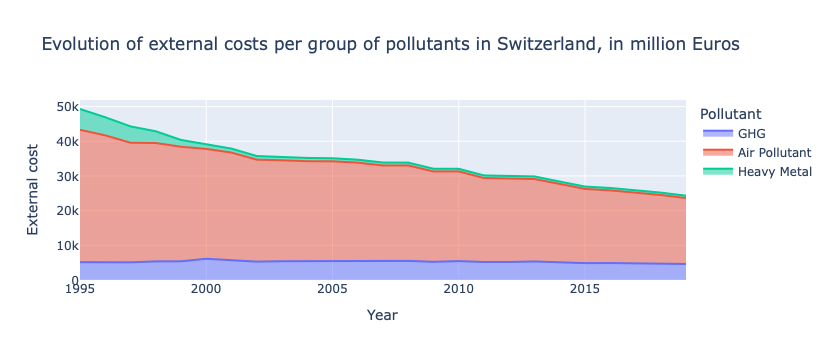

In [36]:
area_cost = px.area(df_cost_ch,         # data frame as input
                   x="Year",            # Years on the x-axis (data frame column name)
                   y="External cost",   # External cost value on the y-axis (data frame column name)
                   color="Pollutant",   # Color by group of pollutants    (data frame column name)
                   title = "Evolution of external costs per group of pollutants in Switzerland, in million Euros"  #Title
                  )
area_cost.show()

We observe that the external costs due to heavy metals are decreasing. The spread of unleaded gasoline during the 1990s, coupled with the implementation of the 1998 Aarhus Protocol on Heavy Metals, explains this reduction.

The external costs due to air pollutants are also decreasing due to, among others, a reduction in nitrogen
oxides (NO$_x$) emissions generated by the application of nitrogen fertilizers, more efficient heating systems and better buildings' insulation, and more efficient vehicles.

However, the trend is less pronounced for GHG, showing the difficulty of decarbonizing society.

### GrDP Map <a name="Data-Viz-map"></a>

Let's conclude our discovery our visualization in Python with a last map. Although we did before a bar chart showing the GrDP per capita of European countries, a map is arguably a nicer visualization, and is especially suited to identify geographic patterns.

We first extract the GrDP per capita for each country in 2019.

In [37]:
df_grdp_2019 = df_grdp.loc[df_grdp["Year"]==2019, ["Country", "GrDP per capita [Euro]"]]

We now design our map, using `plotly.express.choropleth` ([Documentation](https://plotly.github.io/plotly.py-docs/generated/plotly.express.choropleth.html)), which we previously used to create a world map of altruism. We will play a bit with the options to discover some new functionalities. In particular, there are plenty of [map configuration and styling](https://plotly.com/python/map-configuration/) and [color options](https://plotly.com/python/builtin-colorscales/).

/var/folders/q6/4tq3vy810lv6459v0cdtwnh80000gn/T/ipykernel_7510/1385668959.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  map_grdp = px.choropleth(


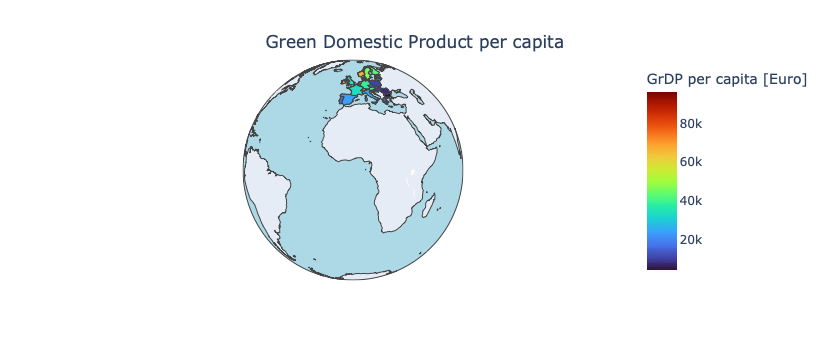

In [38]:
map_grdp = px.choropleth( 
    df_grdp_2019,                                         # dataframe as argument
    locations="Country",                                  # column name with location
    locationmode="country names",                         # location method
    color="GrDP per capita [Euro]",                       # color countries with altruism value
    color_continuous_scale=px.colors.sequential.Turbo     # choice of colors
)

map_grdp.update_layout( 
    title={                                # Add a title, centered on top
        'text': "Green Domestic Product per capita",
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})


map_grdp.update_geos(showocean=True,              # fill ocean with colors
                     oceancolor="LightBlue",      # specify color of oceans
                     projection_type="orthographic")  # specify projection type

map_grdp.show()

Wow! Looks fancy! Ok, you might argue that it was probably too much for what we wanted to do. We did not need a orthographic projection of the globe since we only have data for Europe. And does coloring oceans fit a purpose here? Probably not! And is the choice of colors appropriate? I let you be the judge... So, can you improve this figure? Your turn to play!

### And so much more... Be creative! <a name="Data-Viz-more"></a>

We only grasps the surface of the wonderful world of data visualization. [Treemaps](https://www.python-graph-gallery.com/treemap/) displays hierarchical data as a set of nested rectangles. [Workclouds](https://www.python-graph-gallery.com/wordcloud/) allow to visualize text and the importance of each word/expression inside it. [Venn Diagrams](https://www.python-graph-gallery.com/venn-diagram/) shows possible logical relationships. [Sankey Diagrams](https://www.python-graph-gallery.com/sankey-diagram/) are great to visualize flows (they are often used with energy flows). And so on, and on...

You can also introduce interactive features, bringing your notebook to life allowing users to make decisions and play with your results. If you want to learn more, check for instance [Jupyter Widgets](https://ipywidgets.readthedocs.io/en/stable/index.html).

This is only the beginning of your journey, and we look forward to seeing what you will accomplish!

<img src='https://i.imgflip.com/8186k5.jpg' width="450">